# Curating the FLEURS Dataset with NeMo Curator

This notebook walks through the FLEURS audio curation pipeline step by step:
1. Download a small FLEURS split
2. Run ASR inference
3. Compute WER and duration
4. Filter by WER threshold
5. Inspect and visualize results

**Requirements**: GPU recommended for ASR inference. Install with `uv sync --extra audio_cuda12`.

In [1]:
import json
import os
import shutil

from nemo_curator.backends.xenna import XennaExecutor
from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.audio.common import GetAudioDurationStage, PreserveByValueStage
from nemo_curator.stages.audio.datasets.fleurs.create_initial_manifest import CreateInitialManifestFleursStage
from nemo_curator.stages.audio.inference.asr_nemo import InferenceAsrNemoStage
from nemo_curator.stages.audio.io.convert import AudioToDocumentStage
from nemo_curator.stages.audio.metrics.get_wer import GetPairwiseWerStage
from nemo_curator.stages.resources import Resources
from nemo_curator.stages.text.io.writer import JsonlWriter

/home/aaftabv/curator/data/Curator/.venv/lib/python3.12/site-packages/cosmos_xenna/pipelines/private/resources.py:38: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


## Configuration

Adjust these parameters for your setup:

In [2]:
RAW_DATA_DIR = os.path.abspath("./example_audio/fleurs")
LANG = "en_us"
SPLIT = "dev"
MODEL_NAME = "nvidia/parakeet-tdt-0.6b-v2"
WER_THRESHOLD = 75.0
GPUS = 1.0

RESULT_DIR = os.path.join(RAW_DATA_DIR, "result")
if os.path.isdir(RESULT_DIR):
    shutil.rmtree(RESULT_DIR)

## Step 1: Build the pipeline

The pipeline has 7 stages: download → ASR → WER → duration → filter → convert → write.

In [3]:
pipeline = Pipeline(
    name="fleurs_tutorial",
    description="Download FLEURS, run ASR, filter by WER",
)

pipeline.add_stage(
    CreateInitialManifestFleursStage(lang=LANG, split=SPLIT, raw_data_dir=RAW_DATA_DIR).with_(batch_size=4)
)
pipeline.add_stage(InferenceAsrNemoStage(model_name=MODEL_NAME).with_(resources=Resources(gpus=GPUS)))
pipeline.add_stage(GetPairwiseWerStage(text_key="text", pred_text_key="pred_text", wer_key="wer"))
pipeline.add_stage(GetAudioDurationStage(audio_filepath_key="audio_filepath", duration_key="duration"))
pipeline.add_stage(PreserveByValueStage(input_value_key="wer", target_value=WER_THRESHOLD, operator="le"))
pipeline.add_stage(AudioToDocumentStage().with_(batch_size=1))
pipeline.add_stage(JsonlWriter(path=RESULT_DIR, write_kwargs={"force_ascii": False}))

print(pipeline.describe())

2026-04-20 15:52:32.444 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'CreateInitialManifestFleurs' to pipeline 'fleurs_tutorial'
2026-04-20 15:52:32.445 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'ASR_inference' to pipeline 'fleurs_tutorial'
2026-04-20 15:52:32.445 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'GetPairwiseWerStage' to pipeline 'fleurs_tutorial'
2026-04-20 15:52:32.446 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'GetAudioDurationStage' to pipeline 'fleurs_tutorial'
2026-04-20 15:52:32.446 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'PreserveByValueStage' to pipeline 'fleurs_tutorial'
2026-04-20 15:52:32.446 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'AudioToDocumentStage' to pipeline 'fleurs_tutorial'
2026-04-20 15:52:32.448 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'jsonl_writer' to

Pipeline: fleurs_tutorial
Description: Download FLEURS, run ASR, filter by WER
Stages: 7

Stage 1: CreateInitialManifestFleurs
  Resources: 1.0 CPUs
  Batch size: 4
  Outputs:
    Output columns: audio_filepath, text
Stage 2: ASR_inference
  Resources: 1.0 CPUs
    GPU Memory: 0.0 GB (1.0 GPUs)
  Batch size: 16
  Inputs:
    Required columns: audio_filepath
  Outputs:
    Output columns: audio_filepath, pred_text
Stage 3: GetPairwiseWerStage
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: text, pred_text
  Outputs:
    Output columns: text, pred_text, wer
Stage 4: GetAudioDurationStage
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: audio_filepath
  Outputs:
    Output columns: duration
Stage 5: PreserveByValueStage
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: wer
  Outputs:
    Output columns: wer
Stage 6: AudioToDocumentStage
  Resources: 1.0 CPUs
  Batch size: 1
Stage 7: jsonl_writer
  Resources: 1.0 CPUs
  Batch s

## Step 2: Execute the pipeline

In [4]:
executor = XennaExecutor()
pipeline.run(executor)
print("Pipeline complete!")

2026-04-20 15:52:32.463 | INFO     | nemo_curator.pipeline.pipeline:build:70 - Planning pipeline: fleurs_tutorial
2026-04-20 15:52:32.470 | INFO     | nemo_curator.backends.xenna.executor:execute:135 - Execution mode: STREAMING
2026-04-20 15:52:32,495	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.40.137.232:6379...
2026-04-20 15:52:32,516	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
2026-04-20 15:52:32.529 | INFO     | nemo_curator.backends.xenna.adapter:required_resources:71 - Resources: Resources(cpus=1.0, gpu_memory_gb=0.0, gpus=0.0)
2026-04-20 15:52:32.530 | INFO     | nemo_curator.backends.xenna.adapter:required_resources:71 - Resources: Resources(cpus=1.0, gpu_memory_gb=0.0, gpus=1.0)
2026-04-20 15:52:32.530 | INFO     | nemo_curator.backends.xenna.adapter:required_resources:71 - Resources: Resources(cpus=1.0, gpu_memory_gb=0.0, gpus=0.0)
2026-04-20 15:52:32.530 | INFO     | nemo_curator.backends.xenna.ad

(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo I 2026-04-20 15:52:49 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 1024 tokens


(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo W 2026-04-20 15:52:49 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
(Stage 01 - InferenceAsrNemoStage pid=981078)     Train config : 
(Stage 01 - InferenceAsrNemoStage pid=981078)     use_lhotse: true
(Stage 01 - InferenceAsrNemoStage pid=981078)     skip_missing_manifest_entries: true
(Stage 01 - InferenceAsrNemoStage pid=981078)     input_cfg: null
(Stage 01 - InferenceAsrNemoStage pid=981078)     tarred_audio_filepaths: null
(Stage 01 - InferenceAsrNemoStage pid=981078)     manifest_filepath: null
(Stage 01 - InferenceAsrNemoStage pid=981078)     sample_rate: 16000
(Stage 01 - InferenceAsrNemoStage pid=981078)     shuffle: true
(Stage 01 - InferenceAsrNemoStage pid=981078)     num_workers: 2
(Stage 01 - InferenceAsrNemoStage pid=981078)     pin_memory: true
(Stage 01 - InferenceAsrNemoStage pi

(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo I 2026-04-20 15:52:49 nemo_logging:393] PADDING: 0


(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo W 2026-04-20 15:52:52 nemo_logging:405] No conditional node support for Cuda.
(Stage 01 - InferenceAsrNemoStage pid=981078)     Cuda graphs with while loops are disabled, decoding speed will be slower
(Stage 01 - InferenceAsrNemoStage pid=981078)     Reason: No `cuda-python` module. Please do `pip install cuda-python>=12.3`
(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo W 2026-04-20 15:52:52 nemo_logging:405] No conditional node support for Cuda.
(Stage 01 - InferenceAsrNemoStage pid=981078)     Cuda graphs with while loops are disabled, decoding speed will be slower
(Stage 01 - InferenceAsrNemoStage pid=981078)     Reason: No `cuda-python` module. Please do `pip install cuda-python>=12.3`


(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo I 2026-04-20 15:52:52 nemo_logging:393] Using RNNT Loss : tdt
(Stage 01 - InferenceAsrNemoStage pid=981078)     Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo I 2026-04-20 15:52:52 nemo_logging:393] Using RNNT Loss : tdt
(Stage 01 - InferenceAsrNemoStage pid=981078)     Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo I 2026-04-20 15:52:52 nemo_logging:393] Using RNNT Loss : tdt
(Stage 01 - InferenceAsrNemoStage pid=981078)     Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}


(Stage 01 - InferenceAsrNemoStage pid=981078) Using blocking ray.get inside async actor. This blocks the event loop. Please use `await` on object ref with asyncio.gather if you want to yield execution to the event loop instead.
Transcribing:   0%|          | 0/4 [00:00<?, ?it/s] 


(Stage 01 - InferenceAsrNemoStage pid=981078) [NeMo I 2026-04-20 15:52:54 nemo_logging:393] Model EncDecRNNTBPEModel was successfully restored from /home/aaftabv/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v2/snapshots/48b630d20b000e5ad3735e5378a2d9bde3f80826/parakeet-tdt-0.6b-v2.nemo.


Transcribing:   0%|          | 0/4 [00:00<?, ?it/s] 
(Stage 06 - JsonlWriter pid=981090) 2026-04-20 15:52:55.159 | WARNING  | nemo_curator.stages.text.io.writer.base:process:79 - The task does not have source_files in metadata, using UUID for base filename
(Stage 06 - JsonlWriter pid=981090) 2026-04-20 15:52:55.161 | WARNING  | nemo_curator.stages.text.io.writer.base:process:79 - The task does not have source_files in metadata, using UUID for base filename
(Stage 06 - JsonlWriter pid=981090) 2026-04-20 15:52:55.190 | WARNING  | nemo_curator.stages.text.io.writer.base:process:79 - The task does not have source_files in metadata, using UUID for base filename
(Stage 06 - JsonlWriter pid=981090) 2026-04-20 15:52:55.191 | WARNING  | nemo_curator.stages.text.io.writer.base:process:79 - The task does not have source_files in metadata, using UUID for base filename
(Stage 06 - JsonlWriter pid=981090) 2026-04-20 15:52:55.222 | WARNING  | nemo_curator.stages.text.io.writer.base:process:79 - The t

Pipeline complete!


## Step 3: Load and inspect results

In [5]:
results = []
for fname in os.listdir(RESULT_DIR):
    if fname.endswith(".jsonl"):
        with open(os.path.join(RESULT_DIR, fname)) as f:
            for line in f:
                if line.strip():
                    results.append(json.loads(line))

print(f"Total samples after filtering: {len(results)}")
print("\nSample entry:")
print(json.dumps(results[0], indent=2, ensure_ascii=False) if results else "No results")

Total samples after filtering: 394

Sample entry:
{
  "audio_filepath": "/home/aaftabv/curator/data/Curator/tutorials/audio/fleurs/example_audio/fleurs/dev/5138563835183207037.wav",
  "text": "The winter can be deceptively chilly: temperatures rarely go below freezing, but the wind and humidity combine to make it feel colder than what the thermometer says.",
  "pred_text": "The winter can be deceptively chilly, temperatures rarely go below freezing, but the wind and humidity combine to make it feel colder than what the thermometer says.",
  "wer": 3.7,
  "duration": 12.24
}


## Step 4: Visualize results

### WER distribution

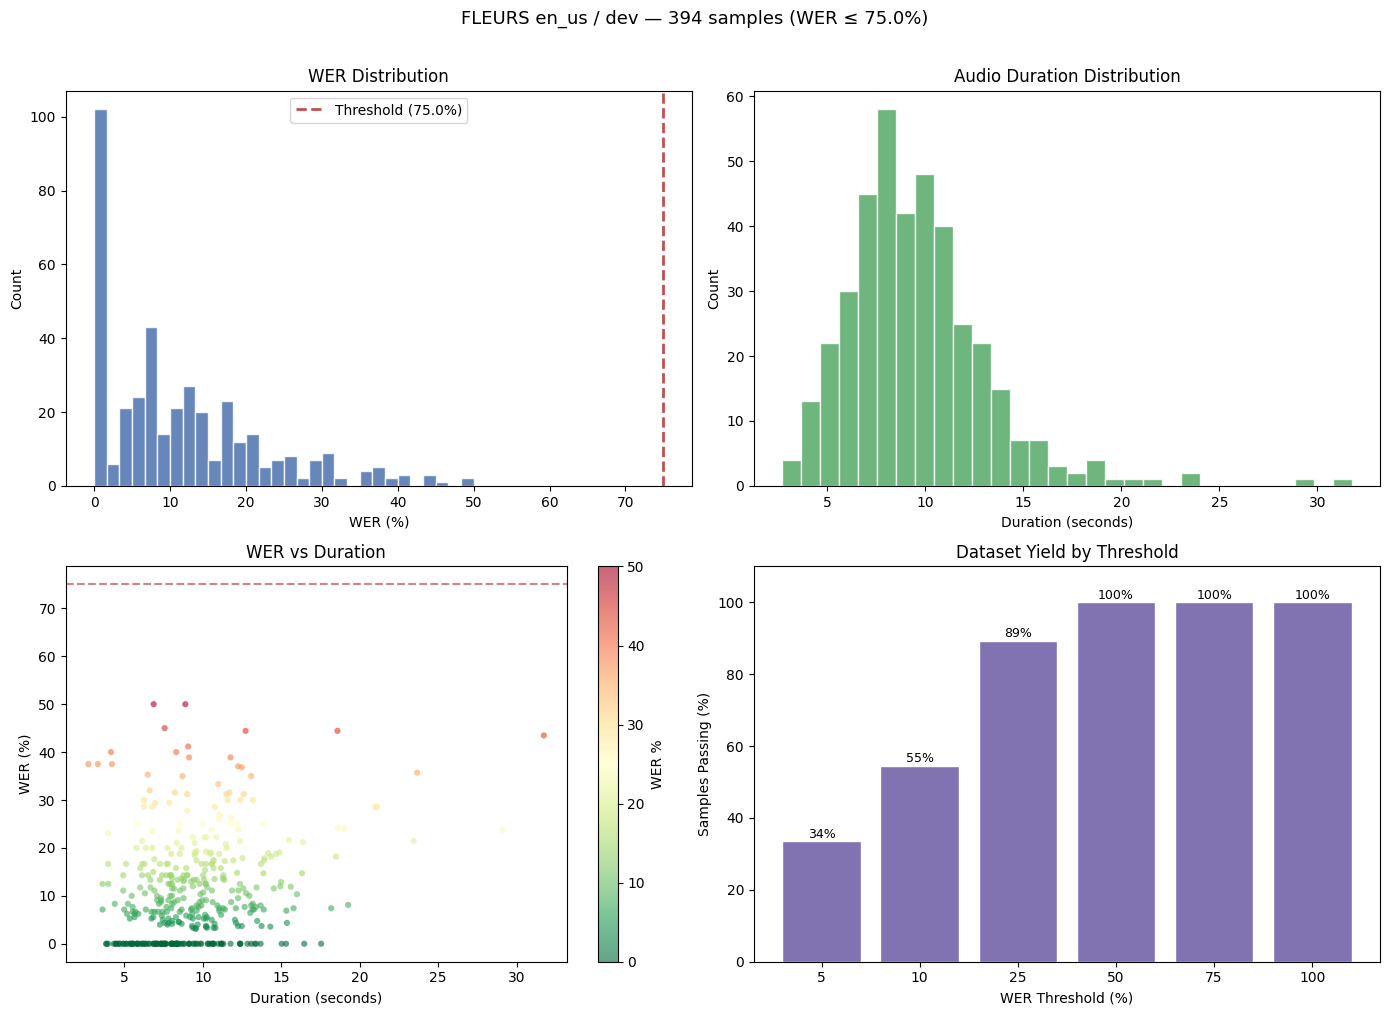


WER — min: 0.0%, max: 50.0%, mean: 11.3%, median: 8.7%
Duration — min: 2.70s, max: 31.74s, total: 3765.2s


In [6]:
import matplotlib.pyplot as plt
import numpy as np

wers = [r.get("wer", 0) for r in results]
durations = [r.get("duration", 0) for r in results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. WER histogram with threshold line
ax = axes[0, 0]
ax.hist(wers, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(WER_THRESHOLD, color="#C44E52", linestyle="--", linewidth=2, label=f"Threshold ({WER_THRESHOLD}%)")
ax.set_xlabel("WER (%)")
ax.set_ylabel("Count")
ax.set_title("WER Distribution")
ax.legend()

# 2. Duration distribution
ax = axes[0, 1]
ax.hist(durations, bins=30, color="#55A868", edgecolor="white", alpha=0.85)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Count")
ax.set_title("Audio Duration Distribution")

# 3. WER vs Duration scatter
ax = axes[1, 0]
scatter = ax.scatter(durations, wers, c=wers, cmap="RdYlGn_r", alpha=0.6, s=20, edgecolors="none")
ax.axhline(WER_THRESHOLD, color="#C44E52", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("WER (%)")
ax.set_title("WER vs Duration")
plt.colorbar(scatter, ax=ax, label="WER %")

# 4. Pass rate at multiple thresholds
ax = axes[1, 1]
thresholds = [5, 10, 25, 50, 75, 100]
pass_rates = [sum(1 for w in wers if w <= t) / len(wers) * 100 for t in thresholds]
bars = ax.bar([str(t) for t in thresholds], pass_rates, color="#8172B2", edgecolor="white")
ax.set_xlabel("WER Threshold (%)")
ax.set_ylabel("Samples Passing (%)")
ax.set_title("Dataset Yield by Threshold")
for bar, rate in zip(bars, pass_rates, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{rate:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 110)

fig.suptitle(f"FLEURS {LANG} / {SPLIT} — {len(results)} samples (WER ≤ {WER_THRESHOLD}%)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

print(
    f"\nWER — min: {min(wers):.1f}%, max: {max(wers):.1f}%, mean: {np.mean(wers):.1f}%, median: {np.median(wers):.1f}%"
)
print(f"Duration — min: {min(durations):.2f}s, max: {max(durations):.2f}s, total: {sum(durations):.1f}s")

## Step 5: Experiment with different thresholds

Try changing the WER threshold to see how it affects the dataset size:

In [7]:
thresholds = [10, 25, 50, 75, 100]
for t in thresholds:
    passing = [r for r in results if r.get("wer", 100) <= t]
    pct = len(passing) / len(results) * 100 if results else 0
    print(f"  WER ≤ {t:3d}%: {len(passing):4d} samples ({pct:.0f}%)")

  WER ≤  10%:  215 samples (55%)
  WER ≤  25%:  352 samples (89%)
  WER ≤  50%:  394 samples (100%)
  WER ≤  75%:  394 samples (100%)
  WER ≤ 100%:  394 samples (100%)
